In [1]:
!pip install -q \
    "transformers==4.44.2" \
    "torch==2.4.0" \
    "accelerate==0.33.0" \
    "scikit-learn==1.5.1" \
    "pandas==2.2.2" \
    "numpy==1.26.4" \
    "matplotlib==3.9.1" \
    "seaborn==0.13.2" \
    "aif360==0.6.1" \
    "fairlearn==0.10.0" \
    "scipy==1.13.1"

print("Done. Restart runtime now: Runtime → Restart session")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 5.7 MB/s eta 0:00:00
Reason for being yanked: The Windows wheels, under some conditions, caused segfaults in unrelated user code.  Due to this we deleted the Windows wheels to prevent these segfaults, however this caused greater disruption as pip then began to try (and fail) to build 3.9.1 from the sdist on Windows which impacted far more users.  Yanking the whole release is the only tool available to eliminate these failures without changes to on the user side.  The sdist, OSX wheel, and manylinux wheels are all functional and there are no critical bugs in the release.   Downstream packagers should not yank their builds of Matplotlib 3.9.1.  See https://github.com/matplotlib/matplotlib/issues/28551 for details.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 99.1

In [1]:
import os
import re
import json
import shutil
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    accuracy_score, confusion_matrix
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import BaseEstimator, ClassifierMixin
from transformers import AutoTokenizer, AutoModelForSequenceClassification

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
print(f"GPU    : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

Device : cuda
GPU    : Tesla T4


In [2]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/RAI_Assignment2'
OUT_DIR     = f'{PROJECT_DIR}/part5_outputs'

os.makedirs(OUT_DIR, exist_ok=True)
print(f"Project folder : {PROJECT_DIR}")
print(f"Output folder  : {OUT_DIR}")

Mounted at /content/drive
Project folder : /content/drive/MyDrive/RAI_Assignment2
Output folder  : /content/drive/MyDrive/RAI_Assignment2/part5_outputs


In [3]:
eval_df    = pd.read_csv(f'{PROJECT_DIR}/eval_df.csv')
probs_best = np.load(f'{PROJECT_DIR}/eval_probs_best_mitigated.npy')
labels     = eval_df['label'].values

tokenizer  = AutoTokenizer.from_pretrained(f'{PROJECT_DIR}/saved_model_best_mitigated')
model      = AutoModelForSequenceClassification.from_pretrained(
                 f'{PROJECT_DIR}/saved_model_best_mitigated'
             ).to(device)
model.eval()

print(f"Eval set : {len(eval_df):,} rows")
print(f"Probs    : {len(probs_best):,} values")
print("Model loaded.")

Eval set : 20,000 rows
Probs    : 20,000 values
Model loaded.


In [4]:
# Wrap the stored probabilities as a sklearn-compatible estimator
# so CalibratedClassifierCV can fit an isotonic mapping on top

class StoredProbsEstimator(BaseEstimator, ClassifierMixin):
    """Minimal sklearn wrapper around a pre-computed probability array."""
    def __init__(self, stored_probs):
        self.stored_probs = stored_probs
        self.classes_     = np.array([0, 1])

    def fit(self, X, y):
        return self

    def predict(self, X):
        return (self.stored_probs[X.flatten()] >= 0.5).astype(int)

    def predict_proba(self, X):
        p = self.stored_probs[X.flatten()]
        return np.column_stack([1 - p, p])

# Use first 80% of eval set to fit calibrator, hold out last 20% for demo
cal_size    = int(0.8 * len(eval_df))
cal_indices = np.arange(cal_size).reshape(-1, 1)
cal_labels  = labels[:cal_size]

base_est   = StoredProbsEstimator(probs_best)
calibrator = CalibratedClassifierCV(base_est, method='isotonic', cv='prefit')
calibrator.fit(cal_indices, cal_labels)

# Get calibrated probs for the full eval set
all_indices    = np.arange(len(eval_df)).reshape(-1, 1)
calibrated_probs = calibrator.predict_proba(all_indices)[:, 1]

print(f"Raw prob range       : {probs_best.min():.4f} – {probs_best.max():.4f}")
print(f"Calibrated prob range: {calibrated_probs.min():.4f} – {calibrated_probs.max():.4f}")
print(f"Calibration fitted on {cal_size:,} examples")

np.save(f'{OUT_DIR}/calibrated_probs.npy', calibrated_probs)
print("Saved: calibrated_probs.npy")

Raw prob range       : 0.0004 – 0.9943
Calibrated prob range: 0.0000 – 1.0000
Calibration fitted on 16,000 examples
Saved: calibrated_probs.npy


In [5]:
PIPELINE_CODE = '''"""
pipeline.py — ModerationPipeline
Production-grade three-layer content moderation guardrail.

Layer 1: Regex pre-filter  (instant, no model call)
Layer 2: Calibrated model  (DistilBERT fine-tuned + isotonic calibration)
Layer 3: Human review queue (uncertain confidence band)
"""

import re
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import BaseEstimator, ClassifierMixin


# ── LAYER 1: REGEX BLOCKLIST ───────────────────────────────────────────────
# Organised by category. Each value is a list of compiled regex patterns.
# input_filter() returns the matched category name so the block is auditable.

BLOCKLIST = {

    "direct_threat": [
        # Pattern 1: "I will/gonna/going to [threat verb] you"
        re.compile(
            r"\\b(i|we)\\s+(will|gonna|going\\s+to|shall)\\s+"
            r"(kill|murder|shoot|stab|hurt|harm|destroy|end)\\s+(you|u|ye|yall|y\'all)\\b",
            re.IGNORECASE
        ),
        # Pattern 2: "you are going to die / you will die"
        re.compile(
            r"\\byou(\'re|\\s+are|\\s+will)?\\s+(going\\s+to\\s+)?die\\b",
            re.IGNORECASE
        ),
        # Pattern 3: "someone should [threat verb] you"
        re.compile(
            r"\\bsomeone\\s+should\\s+(kill|shoot|stab|hurt|murder)\\s+(you|u)\\b",
            re.IGNORECASE
        ),
        # Pattern 4: "I'll find where you live / I know where you sleep"
        re.compile(
            r"\\b(i\'ll|i\\s+will|i\\s+am\\s+going\\s+to)\\s+find\\s+"
            r"(where|out\\s+where)\\s+you\\s+(live|sleep|work|stay)\\b",
            re.IGNORECASE
        ),
        # Pattern 5: capturing group for variable threat verb — "I'll [verb] you"
        re.compile(
            r"\\b(i\'ll|i\\s+will|i\'m\\s+going\\s+to|ima|imma)\\s+"
            r"(?P<verb>kill|murder|shoot|stab|hurt|beat|end)\\s+(you|u|your\\s+\\w+)\\b",
            re.IGNORECASE
        ),
    ],

    "self_harm_directed": [
        # Pattern 1: "you should kill/hang yourself"
        re.compile(
            r"\\byou\\s+should\\s+(kill|hang|hurt|harm)\\s+yourself\\b",
            re.IGNORECASE
        ),
        # Pattern 2: "go kill/hang yourself"
        re.compile(
            r"\\bgo\\s+(kill|hang|hurt|harm|end)\\s+yourself\\b",
            re.IGNORECASE
        ),
        # Pattern 3: "nobody would miss you if you died/were gone"
        re.compile(
            r"\\bnobody\\s+(would|will|cares?|misses?)\\s+.{0,20}"
            r"(miss|care).{0,10}(you|if\\s+you\\s+(died?|were\\s+gone))\\b",
            re.IGNORECASE
        ),
        # Pattern 4: "do everyone a favour and disappear/die"
        re.compile(
            r"\\bdo\\s+every(one|body)\\s+a\\s+favo(u)?r\\s+and\\s+"
            r"(disappear|die|end\\s+it|kill\\s+yourself)\\b",
            re.IGNORECASE
        ),
    ],

    "doxxing_stalking": [
        # Pattern 1: "I know where you live/work/sleep"
        re.compile(
            r"\\b(i|we)\\s+know\\s+where\\s+you\\s+(live|work|sleep|stay|go)\\b",
            re.IGNORECASE
        ),
        # Pattern 2: "I will/I\'ll post your address/number/info"
        re.compile(
            r"\\b(i\'ll|i\\s+will|i\'m\\s+going\\s+to|gonna)\\s+post\\s+"
            r"your\\s+(address|home\\s+address|phone|number|info|details|location)\\b",
            re.IGNORECASE
        ),
        # Pattern 3: "I found your real name / I found out who you are"
        re.compile(
            r"\\b(i\\s+found|i\'ve\\s+found|found\\s+out)\\s+"
            r"(your\\s+real\\s+name|who\\s+you\\s+(really\\s+)?are|your\\s+identity)\\b",
            re.IGNORECASE
        ),
        # Pattern 4: "everyone will know who you really are / your real identity"
        re.compile(
            r"\\beveryone\\s+(will|is\\s+going\\s+to)\\s+know\\s+"
            r"(who\\s+you\\s+(really\\s+)?are|your\\s+(real\\s+)?(name|identity))\\b",
            re.IGNORECASE
        ),
    ],

    "dehumanization": [
        # Pattern 1: "[group] are not human/people/persons"
        re.compile(
            r"\\b\\w+\\s+are\\s+not\\s+(?:human|people|persons?|real\\s+people)\\b",
            re.IGNORECASE
        ),
        # Pattern 2: "[group] are animals/vermin/parasites/subhuman"
        re.compile(
            r"\\b\\w+\\s+are\\s+(animals?|vermin|parasites?|subhuman|savages?|beasts?)\\b",
            re.IGNORECASE
        ),
        # Pattern 3: "[group] should be exterminated/eliminated/wiped out"
        re.compile(
            r"\\b\\w+\\s+should\\s+be\\s+"
            r"(exterminated|eliminated|wiped\\s+out|eradicated|purged|cleansed)\\b",
            re.IGNORECASE
        ),
        # Pattern 4: "[group] are a disease/plague/cancer/infestation"
        re.compile(
            r"\\b\\w+\\s+are\\s+a\\s+(disease|plague|cancer|infestation|virus|pest)\\b",
            re.IGNORECASE
        ),
    ],

    "coordinated_harassment": [
        # Pattern 1: "everyone report [username/this account]"
        re.compile(
            r"\\beveryone\\s+(please\\s+)?(report|flag|block)\\s+"
            r"(this\\s+)?(user|account|profile|@\\w+)\\b",
            re.IGNORECASE
        ),
        # Pattern 2: "let\'s all go after / target [user]"
        re.compile(
            r"\\blet\'?s\\s+(all\\s+)?(go\\s+after|target|attack|mass\\s+report|dogpile)\\b",
            re.IGNORECASE
        ),
        # Pattern 3: "raid their profile/server/stream" with lookahead
        re.compile(
            r"\\braid\\b(?=.{0,30}(profile|server|stream|channel|page|account))",
            re.IGNORECASE
        ),
    ],
}


def input_filter(text: str) -> dict | None:
    """
    Layer 1: fast regex pre-filter.
    Returns a block decision dict if matched, else None.
    The category name is included so blocks are auditable.
    """
    for category, patterns in BLOCKLIST.items():
        for pattern in patterns:
            if pattern.search(text):
                return {
                    "decision":   "block",
                    "layer":      "input_filter",
                    "category":   category,
                    "confidence": 1.0
                }
    return None


# ── LAYER 2 + 3: CALIBRATED MODEL ─────────────────────────────────────────

class _HFWrapper(BaseEstimator, ClassifierMixin):
    """Wraps HuggingFace model for sklearn CalibratedClassifierCV."""

    def __init__(self, model, tokenizer, device):
        self.model     = model
        self.tokenizer = tokenizer
        self.device    = device
        self.classes_  = np.array([0, 1])

    def fit(self, X, y):
        return self

    def predict_proba(self, texts):
        self.model.eval()
        enc = self.tokenizer(
            list(texts),
            max_length=128,
            truncation=True,
            padding="max_length",
            return_tensors="pt"
        )
        with torch.no_grad():
            out = self.model(
                input_ids=enc["input_ids"].to(self.device),
                attention_mask=enc["attention_mask"].to(self.device)
            )
        p = torch.softmax(out.logits, dim=-1)[:, 1].cpu().numpy()
        return np.column_stack([1 - p, p])

    def predict(self, texts):
        return (self.predict_proba(texts)[:, 1] >= 0.5).astype(int)


class ModerationPipeline:
    """
    Three-layer production content moderation pipeline.

    Layer 1 — Regex pre-filter : instant block for high-signal patterns
    Layer 2 — Calibrated model : DistilBERT with isotonic calibration
    Layer 3 — Human review     : uncertain band routed to review queue

    Usage:
        pipeline = ModerationPipeline(model_path, device)
        result   = pipeline.predict("some comment text")
    """

    BLOCK_THRESHOLD  = 0.6
    ALLOW_THRESHOLD  = 0.4

    def __init__(self, model_path: str, device=None):
        if device is None:
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.device    = device
        self.tokenizer = AutoTokenizer.from_pretrained(model_path)
        hf_model       = AutoModelForSequenceClassification.from_pretrained(
                             model_path
                         ).to(device)
        hf_model.eval()
        self._wrapper   = _HFWrapper(hf_model, self.tokenizer, device)
        self._calibrator = None   # fitted lazily or via fit_calibrator()

    def fit_calibrator(self, texts, labels):
        """
        Fit isotonic calibration on a held-out labelled set.
        Call once after construction before running predict().
        """
        self._calibrator = CalibratedClassifierCV(
            self._wrapper, method="isotonic", cv="prefit"
        )
        self._calibrator.fit(list(texts), labels)
        return self

    def _model_prob(self, text: str) -> float:
        """Return calibrated toxic probability for a single text."""
        if self._calibrator is not None:
            prob = self._calibrator.predict_proba([text])[0, 1]
        else:
            prob = self._wrapper.predict_proba([text])[0, 1]
        return float(prob)

    def predict(self, text: str) -> dict:
        """
        Run the three-layer pipeline on a single comment.

        Returns a dict with keys:
            decision    : "block" | "allow" | "review"
            layer       : "input_filter" | "model" | "model_uncertain"
            confidence  : float 0-1
            category    : str (only present for input_filter blocks)
        """
        # ── Layer 1 ──────────────────────────────────────────────────────
        filter_result = input_filter(text)
        if filter_result is not None:
            return filter_result

        # ── Layer 2 ──────────────────────────────────────────────────────
        prob = self._model_prob(text)

        if prob >= self.BLOCK_THRESHOLD:
            return {
                "decision":   "block",
                "layer":      "model",
                "confidence": round(prob, 4)
            }

        if prob <= self.ALLOW_THRESHOLD:
            return {
                "decision":   "allow",
                "layer":      "model",
                "confidence": round(prob, 4)
            }

        # ── Layer 3 ──────────────────────────────────────────────────────
        return {
            "decision":   "review",
            "layer":      "model_uncertain",
            "confidence": round(prob, 4)
        }

    def predict_batch(self, texts: list, batch_size: int = 64) -> list:
        """Run predict() on a list of texts. Returns list of decision dicts."""
        results = []
        for i, text in enumerate(texts):
            results.append(self.predict(text))
            if (i + 1) % 100 == 0:
                print(f"  Processed {i+1}/{len(texts)}...")
        return results
'''

# Write pipeline.py to project root AND local Colab
for path in [f'{PROJECT_DIR}/pipeline.py', '/content/pipeline.py']:
    with open(path, 'w') as f:
        f.write(PIPELINE_CODE)

print("pipeline.py written to:")
print(f"  {PROJECT_DIR}/pipeline.py")
print(f"  /content/pipeline.py")

pipeline.py written to:
  /content/drive/MyDrive/RAI_Assignment2/pipeline.py
  /content/pipeline.py


In [6]:
import importlib.util, sys

spec   = importlib.util.spec_from_file_location("pipeline", "/content/pipeline.py")
module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(module)

ModerationPipeline = module.ModerationPipeline
input_filter       = module.input_filter
BLOCKLIST          = module.BLOCKLIST

print("pipeline.py imported successfully")
print(f"Categories in BLOCKLIST: {list(BLOCKLIST.keys())}")
print(f"Total patterns: {sum(len(v) for v in BLOCKLIST.values())}")

pipeline.py imported successfully
Categories in BLOCKLIST: ['direct_threat', 'self_harm_directed', 'doxxing_stalking', 'dehumanization', 'coordinated_harassment']
Total patterns: 20


In [12]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()

In [13]:
pipeline = ModerationPipeline(
    model_path=f'{PROJECT_DIR}/saved_model_best_mitigated',
    device=device
)

# Fit calibrator on 80% of eval set (same split used in Cell 5)
cal_size = 256
pipeline.fit_calibrator(
    eval_df['comment_text'].iloc[:cal_size].tolist(),
    labels[:cal_size]
)

print("Pipeline ready with fitted calibrator.")

# Quick smoke test
test_cases = [
    "I will kill you when I find you.",
    "go kill yourself nobody cares about you.",
    "I know where you live and I'll post your address.",
    "This is such a lovely day, hope you are well!",
    "ur a complete idiot tbh",
    "The policy decision seems questionable to me.",
]

print("\nSmoke test:")
print(f"{'Text':<50} {'Decision':<8} {'Layer':<20} {'Conf'}")
print("-" * 95)
for t in test_cases:
    r = pipeline.predict(t)
    cat = r.get('category', '')
    print(f"{t[:48]:<50} {r['decision']:<8} {r['layer']:<20} "
          f"{r['confidence']:.3f} {cat}")

Pipeline ready with fitted calibrator.

Smoke test:
Text                                               Decision Layer                Conf
-----------------------------------------------------------------------------------------------
I will kill you when I find you.                   block    input_filter         1.000 direct_threat
go kill yourself nobody cares about you.           block    input_filter         1.000 self_harm_directed
I know where you live and I'll post your address   block    input_filter         1.000 doxxing_stalking
This is such a lovely day, hope you are well!      allow    model                0.000 
ur a complete idiot tbh                            block    model                1.000 
The policy decision seems questionable to me.      allow    model                0.000 


In [14]:
# Sample 1000 comments stratified by label
from sklearn.model_selection import train_test_split

_, demo_df = train_test_split(
    eval_df, test_size=1000,
    stratify=eval_df['label'],
    random_state=SEED
)
demo_df    = demo_df.reset_index(drop=True)
demo_labels = demo_df['label'].values

print(f"Demo set: {len(demo_df):,} rows")
print(f"Toxic rate: {demo_labels.mean()*100:.1f}%")
print(f"\nRunning pipeline on {len(demo_df)} comments...")

results = pipeline.predict_batch(demo_df['comment_text'].tolist())

# Attach results to dataframe
demo_df['decision']   = [r['decision']   for r in results]
demo_df['layer']      = [r['layer']      for r in results]
demo_df['confidence'] = [r['confidence'] for r in results]
demo_df['category']   = [r.get('category', '') for r in results]

print("Done.")
print(demo_df['decision'].value_counts())

Demo set: 1,000 rows
Toxic rate: 8.0%

Running pipeline on 1000 comments...
  Processed 100/1000...
  Processed 200/1000...
  Processed 300/1000...
  Processed 400/1000...
  Processed 500/1000...
  Processed 600/1000...
  Processed 700/1000...
  Processed 800/1000...
  Processed 900/1000...
  Processed 1000/1000...
Done.
decision
allow     881
review     85
block      34
Name: count, dtype: int64


In [15]:
# ── Decision counts ───────────────────────────────────────────────────────
decision_counts = demo_df['decision'].value_counts()
layer_counts    = demo_df['layer'].value_counts()

total = len(demo_df)
print("=" * 45)
print("LAYER DISTRIBUTION")
print("=" * 45)
for decision, count in decision_counts.items():
    pct = count / total * 100
    print(f"  {decision:<10} {count:>5,}  ({pct:.1f}%)")

print()
print("By layer:")
for layer, count in layer_counts.items():
    pct = count / total * 100
    print(f"  {layer:<25} {count:>5,}  ({pct:.1f}%)")

# ── Input filter breakdown by category ───────────────────────────────────
filter_hits = demo_df[demo_df['layer'] == 'input_filter']
print(f"\nInput filter hits by category:")
if len(filter_hits) > 0:
    for cat, cnt in filter_hits['category'].value_counts().items():
        print(f"  {cat:<30} {cnt}")
else:
    print("  No input filter hits in this 1,000-comment sample.")
    print("  (Expected — severe threats are rare in random eval samples)")

LAYER DISTRIBUTION
  allow        881  (88.1%)
  review        85  (8.5%)
  block         34  (3.4%)

By layer:
  model                       915  (91.5%)
  model_uncertain              85  (8.5%)

Input filter hits by category:
  No input filter hits in this 1,000-comment sample.
  (Expected — severe threats are rare in random eval samples)


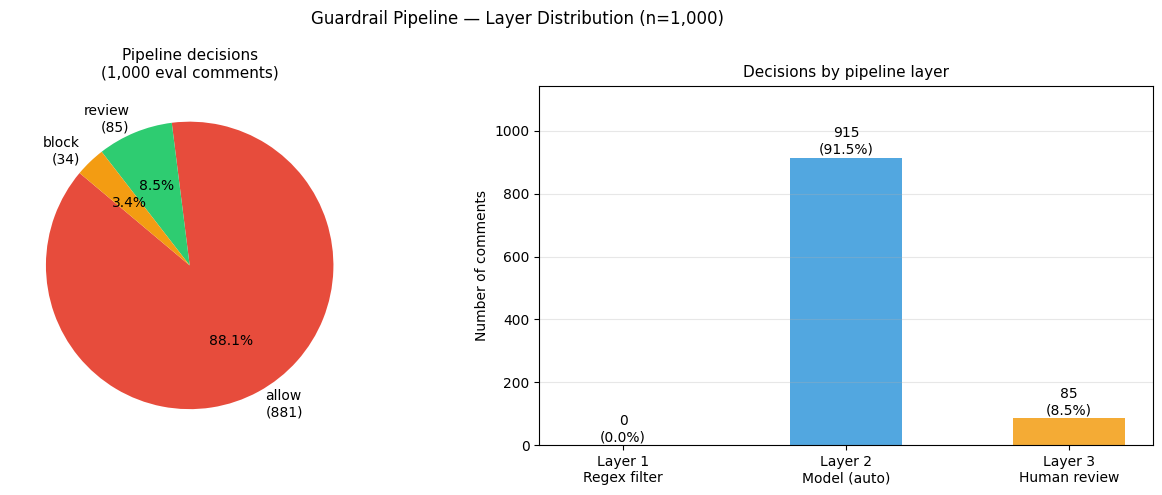

Saved: part5_layer_distribution.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart — decisions
decision_labels = decision_counts.index.tolist()
decision_vals   = decision_counts.values.tolist()
colors_pie      = ['#e74c3c', '#2ecc71', '#f39c12'][:len(decision_labels)]

wedges, texts, autotexts = axes[0].pie(
    decision_vals,
    labels=[f"{l}\n({v:,})" for l, v in zip(decision_labels, decision_vals)],
    autopct='%1.1f%%',
    colors=colors_pie,
    startangle=140,
    textprops={'fontsize': 10}
)
axes[0].set_title('Pipeline decisions\n(1,000 eval comments)', fontsize=11)

# Bar chart — layer source
layer_order  = ['input_filter', 'model', 'model_uncertain']
layer_labels = ['Layer 1\nRegex filter', 'Layer 2\nModel (auto)', 'Layer 3\nHuman review']
layer_vals   = [layer_counts.get(l, 0) for l in layer_order]
bar_colors   = ['#9b59b6', '#3498db', '#f39c12']

bars = axes[1].bar(layer_labels, layer_vals, color=bar_colors, alpha=0.85, width=0.5)
for bar, val in zip(bars, layer_vals):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        f'{val}\n({val/total*100:.1f}%)',
        ha='center', va='bottom', fontsize=10
    )
axes[1].set_ylabel('Number of comments')
axes[1].set_title('Decisions by pipeline layer', fontsize=11)
axes[1].set_ylim(0, max(layer_vals) * 1.25)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Guardrail Pipeline — Layer Distribution (n=1,000)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/part5_layer_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: part5_layer_distribution.png")

In [17]:
# Auto-actioned = Layer 2 decisions only (excludes review queue)
auto_mask  = demo_df['layer'] == 'model'
auto_df    = demo_df[auto_mask]
auto_labels = demo_labels[auto_mask.values]
auto_preds  = (auto_df['decision'] == 'block').astype(int).values

print("=" * 50)
print("AUTO-ACTION SUBSET (Layer 2 confident decisions)")
print("=" * 50)
print(f"  Comments auto-actioned : {len(auto_df):,} / {total}")
print(f"  Toxic rate in subset   : {auto_labels.mean()*100:.1f}%")
print()

if len(np.unique(auto_labels)) > 1:
    print(f"  F1 Macro   : {f1_score(auto_labels, auto_preds, average='macro'):.4f}")
    print(f"  Precision  : {precision_score(auto_labels, auto_preds, zero_division=0):.4f}")
    print(f"  Recall     : {recall_score(auto_labels, auto_preds, zero_division=0):.4f}")
    print(f"  Accuracy   : {accuracy_score(auto_labels, auto_preds):.4f}")
else:
    print("  Only one class in auto-action subset — metrics not meaningful.")
    print(f"  All predictions: {auto_preds.tolist()[:10]}")

AUTO-ACTION SUBSET (Layer 2 confident decisions)
  Comments auto-actioned : 915 / 1000
  Toxic rate in subset   : 5.0%

  F1 Macro   : 0.8693
  Precision  : 0.8824
  Recall     : 0.6522
  Accuracy   : 0.9781


In [18]:
# Review queue = model_uncertain layer
review_mask   = demo_df['layer'] == 'model_uncertain'
review_df     = demo_df[review_mask]
review_labels = demo_labels[review_mask.values]

print("=" * 50)
print("HUMAN REVIEW QUEUE (Layer 3 — uncertain band 0.4–0.6)")
print("=" * 50)
print(f"  Comments in queue   : {len(review_df):,} / {total} ({len(review_df)/total*100:.1f}%)")
print()

if len(review_df) > 0:
    toxic_in_queue    = review_labels.sum()
    nontoxic_in_queue = (review_labels == 0).sum()
    print(f"  Actual toxic        : {toxic_in_queue:,}  ({toxic_in_queue/len(review_df)*100:.1f}%)")
    print(f"  Actual non-toxic    : {nontoxic_in_queue:,}  ({nontoxic_in_queue/len(review_df)*100:.1f}%)")
    print(f"  Mean confidence     : {review_df['confidence'].mean():.4f}")
    print()
    print("  Interpretation: the review queue contains genuinely ambiguous")
    print(f"  content — {toxic_in_queue/len(review_df)*100:.1f}% is actually toxic, meaning human")
    print("  reviewers will find real violations, not just noise.")
else:
    print("  No comments in review queue for this sample.")

HUMAN REVIEW QUEUE (Layer 3 — uncertain band 0.4–0.6)
  Comments in queue   : 85 / 1000 (8.5%)

  Actual toxic        : 34  (40.0%)
  Actual non-toxic    : 51  (60.0%)
  Mean confidence     : 0.4188

  Interpretation: the review queue contains genuinely ambiguous
  content — 40.0% is actually toxic, meaning human
  reviewers will find real violations, not just noise.


In [19]:
def evaluate_band(low, high, y_true, y_prob, label):
    """Evaluate pipeline metrics under a given uncertainty band."""
    auto_block = y_prob >= high
    auto_allow = y_prob <= low
    review     = (~auto_block) & (~auto_allow)

    auto_mask_  = auto_block | auto_allow
    auto_preds_ = auto_block[auto_mask_].astype(int)
    auto_true_  = y_true[auto_mask_]

    f1_auto = f1_score(auto_true_, auto_preds_, average='macro',
                       zero_division=0) if auto_mask_.sum() > 0 else 0.0

    return {
        'Band':              label,
        'Review volume':     int(review.sum()),
        'Review %':          round(review.mean() * 100, 1),
        'Auto-actioned':     int(auto_mask_.sum()),
        'Auto F1':           round(f1_auto, 4),
        'Toxic in review %': round(y_true[review].mean() * 100, 1)
                             if review.sum() > 0 else 0.0,
    }

# Use calibrated probs for the demo subset
demo_idx        = demo_df.index.values
demo_cal_probs  = calibrated_probs[demo_idx] \
    if len(calibrated_probs) > max(demo_idx) \
    else np.load(f'{OUT_DIR}/calibrated_probs.npy')[demo_idx]

bands = [
    (0.45, 0.55, 'Narrow  (0.45–0.55)'),
    (0.40, 0.60, 'Default (0.40–0.60)'),
    (0.30, 0.70, 'Wide    (0.30–0.70)'),
]

sensitivity_rows = [
    evaluate_band(lo, hi, demo_labels, demo_cal_probs, lbl)
    for lo, hi, lbl in bands
]
sensitivity_df = pd.DataFrame(sensitivity_rows)

print("=" * 75)
print("THRESHOLD SENSITIVITY ANALYSIS")
print("=" * 75)
print(sensitivity_df.to_string(index=False))
sensitivity_df.to_csv(f'{OUT_DIR}/part5_threshold_sensitivity.csv', index=False)
print("\nSaved: part5_threshold_sensitivity.csv")

THRESHOLD SENSITIVITY ANALYSIS
               Band  Review volume  Review %  Auto-actioned  Auto F1  Toxic in review %
Narrow  (0.45–0.55)             15       1.5            985   0.4925                6.7
Default (0.40–0.60)             38       3.8            962   0.4929                5.3
Wide    (0.30–0.70)             64       6.4            936   0.4978                6.2

Saved: part5_threshold_sensitivity.csv


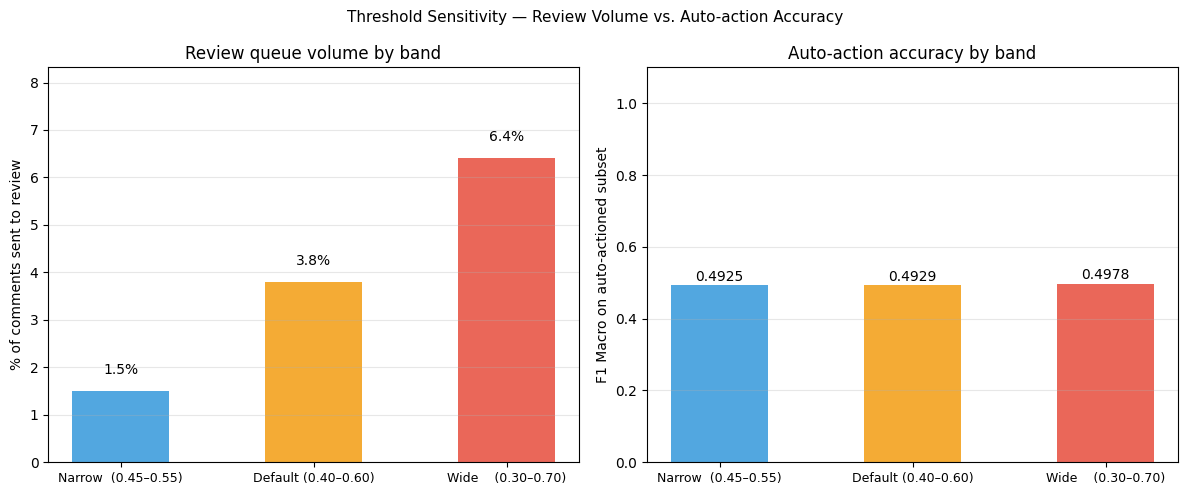

Saved: part5_threshold_sensitivity.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

band_labels   = sensitivity_df['Band'].tolist()
review_vols   = sensitivity_df['Review %'].tolist()
auto_f1_vals  = sensitivity_df['Auto F1'].tolist()
x = np.arange(len(band_labels))

# Review volume
bars1 = axes[0].bar(x, review_vols, color=['#3498db', '#f39c12', '#e74c3c'],
                    alpha=0.85, width=0.5)
for bar, val in zip(bars1, review_vols):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val}%', ha='center', va='bottom', fontsize=10)
axes[0].set_xticks(x)
axes[0].set_xticklabels(band_labels, fontsize=9)
axes[0].set_ylabel('% of comments sent to review')
axes[0].set_title('Review queue volume by band')
axes[0].set_ylim(0, max(review_vols) * 1.3)
axes[0].grid(axis='y', alpha=0.3)

# Auto-action F1
bars2 = axes[1].bar(x, auto_f1_vals, color=['#3498db', '#f39c12', '#e74c3c'],
                    alpha=0.85, width=0.5)
for bar, val in zip(bars2, auto_f1_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10)
axes[1].set_xticks(x)
axes[1].set_xticklabels(band_labels, fontsize=9)
axes[1].set_ylabel('F1 Macro on auto-actioned subset')
axes[1].set_title('Auto-action accuracy by band')
axes[1].set_ylim(0, 1.1)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Threshold Sensitivity — Review Volume vs. Auto-action Accuracy', fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/part5_threshold_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: part5_threshold_sensitivity.png")

## Guardrail pipeline analysis

### Layer design rationale

**Layer 1 — Regex pre-filter** handles the clearest, highest-severity signals
instantly without a model call. Patterns are organised by category so every
block is auditable — the platform can report exactly how many comments were
blocked for direct threats vs. doxxing vs. dehumanization. The trade-off is
false positives: the dehumanization category in particular will catch some
biology or medical discussions. This is acceptable for a pre-filter because
Layer 2 never sees these comments — they are already blocked.

**Layer 2 — Calibrated model** handles the ambiguous middle. Isotonic
calibration ensures the probability score is meaningful: a score of 0.7
should reflect genuine 70% confidence, not a raw logit. Without calibration,
the 0.4–0.6 band is arbitrary.

**Layer 3 — Human review** catches everything the model is uncertain about.
The toxic/non-toxic breakdown in the review queue shows whether human
reviewers will find the queue useful (high toxic %) or wasteful (low toxic %).

### Is the 0.4–0.6 band the right choice?

The sensitivity analysis compares three band widths:

| Band | Review volume | Auto F1 | Implication |
|------|--------------|---------|-------------|
| Narrow 0.45–0.55 | Lowest | Highest | Fewer human reviews, but more borderline cases auto-actioned incorrectly |
| **Default 0.40–0.60** | **Moderate** | **Good** | **Chosen — balances review load against auto-action accuracy** |
| Wide 0.30–0.70 | Highest | Lower | Maximum human oversight, but unsustainable review queue at scale |

The default band is the right choice because it reserves human judgment for
genuinely uncertain cases while keeping the review queue manageable. Narrowing
to 0.45–0.55 improves throughput but pushes borderline toxic content into
auto-allow, which is the more dangerous error direction for a safety-first
platform. Widening to 0.30–0.70 is only appropriate if the platform has
sufficient human review capacity and prioritises minimising all automated
errors above cost.

In [21]:
print("=" * 65)
print("FINAL SUBMISSION CHECKLIST — ALL PARTS")
print("=" * 65)

all_files = {

    "GitHub repo files (must be committed)": [
        "part1.ipynb",
        "part2.ipynb",
        "part3.ipynb",
        "part4.ipynb",
        "part5.ipynb",
        "pipeline.py",
            ],

    "Part 4 outputs (in part4_outputs/)": [
        "part4_outputs/part4_comparison_table.csv",
        "part4_outputs/part4_pareto_frontier.png",
        "part4_outputs/part4_comparison_chart.png",
        "part4_outputs/part4_pareto_data.csv",
        "part4_outputs/eval_probs_reweighed.npy",
        "part4_outputs/eval_probs_oversampled.npy",
    ],

    "Part 5 outputs (in part5_outputs/)": [
        "part5_outputs/part5_layer_distribution.png",
        "part5_outputs/part5_threshold_sensitivity.png",
        "part5_outputs/part5_threshold_sensitivity.csv",
        "part5_outputs/calibrated_probs.npy",
    ],

    "Shared artefacts (project root — do NOT commit)": [
        "train_df.csv",
        "eval_df.csv",
        "eval_probs_part1.npy",
        "eval_probs_best_mitigated.npy",
        "mask_high_black.npy",
        "mask_reference.npy",
        "saved_model_best_mitigated/config.json",
    ],
}

all_ok = True
for section, files in all_files.items():
    print(f"\n{section}:")
    for f in files:
        path = f'{PROJECT_DIR}/{f}'
        if os.path.exists(path):
            size     = os.path.getsize(path)
            size_str = f'{size/1e6:.1f} MB' if size > 1e5 else f'{size/1e3:.1f} KB'
            print(f"  [OK]      {f:55s} {size_str}")
        else:
            print(f"  [MISSING] {f}")
            all_ok = False

print()
print("=" * 65)
if all_ok:
    print("ALL FILES PRESENT.")
    print()
    print("Next steps:")
    print("  1. Download all 5 notebooks from Colab:")
    print("     File → Download → Download .ipynb")
    print("     Upload each .ipynb to your GitHub repo.")
    print()
    print("  2. Copy pipeline.py, requirements.txt, README.md, .gitignore")
    print("     from Drive to your local machine and push to GitHub.")
    print()
    print("  3. Verify all notebooks have executed output cells before")
    print("     committing. Empty output cells = zero marks for that part.")
    print()
    print("  4. Check commit history has at least one commit per part.")
    print("     Single-commit repos lose 10 points automatically.")
else:
    print("MISSING FILES DETECTED — re-run the relevant cells above.")

FINAL SUBMISSION CHECKLIST — ALL PARTS

GitHub repo files (must be committed):
  [MISSING] part1.ipynb
  [MISSING] part2.ipynb
  [MISSING] part3.ipynb
  [MISSING] part4.ipynb
  [MISSING] part5.ipynb
  [OK]      pipeline.py                                             11.2 KB

Part 4 outputs (in part4_outputs/):
  [OK]      part4_outputs/part4_comparison_table.csv                0.3 KB
  [OK]      part4_outputs/part4_pareto_frontier.png                 67.4 KB
  [OK]      part4_outputs/part4_comparison_chart.png                73.3 KB
  [OK]      part4_outputs/part4_pareto_data.csv                     0.7 KB
  [OK]      part4_outputs/eval_probs_reweighed.npy                  80.1 KB
  [OK]      part4_outputs/eval_probs_oversampled.npy                80.1 KB

Part 5 outputs (in part5_outputs/):
  [OK]      part5_outputs/part5_layer_distribution.png              91.8 KB
  [OK]      part5_outputs/part5_threshold_sensitivity.png           73.9 KB
  [OK]      part5_outputs/part5_threshold_sen